In [1]:
%config InlineBackend.figure_format = 'svg'
import os
if os.path.basename(os.getcwd()) == 'notebook': os.chdir('..')
fs_base = 20
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams.update({
    'font.size': fs_base-2,               # 默认字体大小
    'axes.titlesize': fs_base+2,         # 坐标轴标题大小
    'axes.labelsize': fs_base,         # 坐标轴标签大小
    'xtick.labelsize': fs_base-2,       # x轴刻度标签大小
    'ytick.labelsize': fs_base-2,       # y轴刻度标签大小
    'legend.fontsize': fs_base-2,       # 图例字体大小
    'figure.titlesize': fs_base+2       # 图形标题大小
})

In [2]:
import pandas as pd
import numpy as np
import json
import logging
import collections
from models.Models import HGS_Interpret
from utils.data_utils import *
from utils.hg_ops import *
import torch
from torch import optim
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind,pearsonr,mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.colors as mcolors
from sklearn.impute import KNNImputer
from utils.Interpret import *
from utils.plots import *

from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
# from matplotlib.colors import LinearSegmentedColormap


KM ScReg

In [3]:
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
path = "data/XAI/HCC_JXG_Original_data/"
fn_g=path+"Gao_ProteinExpr.ensg.csv"
fn_j=path+"Jiang_ProteinExpr.ensg.csv"
fn_x=path+"xing_ProteinExpr.ensg.csv"
fn_xai_pro = "data/XAI/Proteins_XAIscores.json"
with open(fn_xai_pro, 'r') as f:
    XAI = json.load(f)# test
df_g = pd.read_csv(fn_g,index_col=0).loc[XAI['proteins'],:].T
df_j = pd.read_csv(fn_j,index_col=0).loc[XAI['proteins'],:].T
df_x = pd.read_csv(fn_x,index_col=0).loc[XAI['proteins'],:].T
dfs = [df_g,df_j,df_x]

##  模型载入
torch.cuda.set_device('cuda:0')
Model = "HGS"
DATA="PRO"

HD = {'AGG': 'cat', 'num_hgat': 'single', 'depth': 2, 'l2': 0.1, 'lr': 0.01, 'glr': 0, 'type_atten': 'additive', 
'n_hid': 200, 'gamma': 0.99, 'patience': 5, 'update_freq': 1, 'score': 'harmonic score', 'metric_update': 'score', 
'train_scheme': 'final_epoch', 'MLP_hiddens': [200], 'predict_hiddens': [200, 100], 'model': 'HGS', 'dataset': 'HCC', 
'epochs': 50, 'print_freq': 10, 'batch_size': 32, 'cox_num': 400, 'dropout': 0.5, 'ACT': 'LeakyReLU', 
'pooling_hiddens': [59, 5], 'RESNET': False, 'repeat_time': 10, 'end_point': 'OS_60', 'edge_pooling': True, 
'loss_w': {'a': 1, 'b': 1, 'c1': 1, 'c2': 0, 'd': 1}, 'pooling_method': 'linear', 'n_trials': 20, 'BayeOpt': False, 
'JM': 'final', 'feature_base': 'STRING', 'num_min': 25, 'HG_BN': True, 'n_hp_ckpt': 11,	"atten_type": 'single',}
PK_D= {'type_know': 'hcluster', 'method': 'weighted', 'criterion': 'maxclust', 'num_clusters': 59, 'divisor': 10}
seed = HD['seed']= 7
dataset = 'HCC'
dn_data = f"data/{DATA}/{dataset}/"
data,H = load_cohort_data(None,dn_data+"/dataset.csv",HD['cox_num'],DF=True) 
data_train,data_valid,df_test,t_obs,H_df = data_split(seed=seed,dataset=dataset,data=data,HD=PK_D,construct_H=True,H_df=True,test_df=True)

data_test = df_test.values
H = H_df.values
G = generate_G_from_H(H.T) if HD["edge_pooling"] else generate_G_from_H(H)
logger.info(f"H:{H.shape}; data:{data.shape}; G:{G.shape}; t_obs:{t_obs}")

# 超图池化层、预测头隐藏层节点数
# HD['predict_hiddens']=build_deep_hiddens(num_ini=n*HD['n_hid'],divisor=2,num_min=num_min,depth=HD['depth'])
logger.info(f"{dataset} Best Paras:seed{HD['seed']};L2{HD['l2']};lr{HD['lr']};glr{HD['glr']};agg{HD['AGG']};ph{HD['predict_hiddens']}")				
HD['pooling_hiddens']=build_hiddens(H.shape[1],PK_D['divisor'])
logger.info(f"Pooling_hiddens:{HD['pooling_hiddens']}\n")
out_path = f"Results/Interpret/{DATA}-{dataset}-{PK_D['type_know']}/"
# out_path+= str(list(HD.items())[:HD['n_hp_ckpt']]).replace("), (","-").replace(",",":").replace("'","").replace(" ","")[2:-2]
# out_path+="-"+str(list(PK_D.items())).replace("), (","-").replace(",",":").replace("'","").replace(" ","")[2:-2]
os.makedirs(out_path,exist_ok=True)
fn_ckpt = out_path+f"/{Model}-{dataset}.ckpt"
# 由于计算borda score需要用到模型层结构信息，因此需要初始化模型
model = HGS_Interpret(HD,data_train=data_train,data_eval=data_valid,data_test = data_test,H=H,fn_ckpt=fn_ckpt,t_obs=t_obs,G=G,seed=seed)
model = model.cuda()
if os.path.isfile(fn_ckpt):
	logger.info(f'Using existing {fn_ckpt}.ckpt')
	model.load_state_dict(torch.load(fn_ckpt)['state_dict'])
else: 
    optimizer = optim.Adam(model.parameters(), lr=HD['lr'],weight_decay=HD['l2'])
    model = model.fit(optimizer=optimizer,logger=logger,num_epochs=HD["epochs"],batch_size=HD["batch_size"],loss_dict=HD['loss_w'])



2026-06-23 12:12:26,377 - __main__ - INFO - H:(400, 59); data:(412, 402); G:(59, 59); t_obs:44.0
2026-06-23 12:12:26,378 - __main__ - INFO - HCC Best Paras:seed7;L20.1;lr0.01;glr0;aggcat;ph[200, 100]
2026-06-23 12:12:26,379 - __main__ - INFO - Pooling_hiddens:[59, 5]



Hyperedges computed by Pearson-Hcluster= 59


2026-06-23 12:12:47,615 - __main__ - INFO - --------------------
2026-06-23 12:12:47,621 - __main__ - INFO - Epoch 0/50
2026-06-23 12:12:47,850 - __main__ - INFO - Updating eval ci: 0.645821; eval loss: 52.292065
2026-06-23 12:12:50,705 - __main__ - INFO - --------------------
2026-06-23 12:12:50,707 - __main__ - INFO - Epoch 10/50
2026-06-23 12:12:50,937 - __main__ - INFO - Updating eval ci: 0.790740; eval loss: 57.606926
2026-06-23 12:12:53,817 - __main__ - INFO - --------------------
2026-06-23 12:12:53,822 - __main__ - INFO - Epoch 20/50
2026-06-23 12:12:54,050 - __main__ - INFO - Updating eval ci: 0.761876; eval loss: 55.930397
2026-06-23 12:12:56,735 - __main__ - INFO - --------------------
2026-06-23 12:12:56,736 - __main__ - INFO - Epoch 30/50
2026-06-23 12:12:56,968 - __main__ - INFO - Updating eval ci: 0.757066; eval loss: 51.071373
2026-06-23 12:12:59,914 - __main__ - INFO - --------------------
2026-06-23 12:12:59,916 - __main__ - INFO - Epoch 40/50
2026-06-23 12:13:00,140 

High risk group size: 41 Low risk group size: 42
median risk:21.791385650634766
 Log-rank p-value: 2.515747975600761e-06
Plotting survival curve 


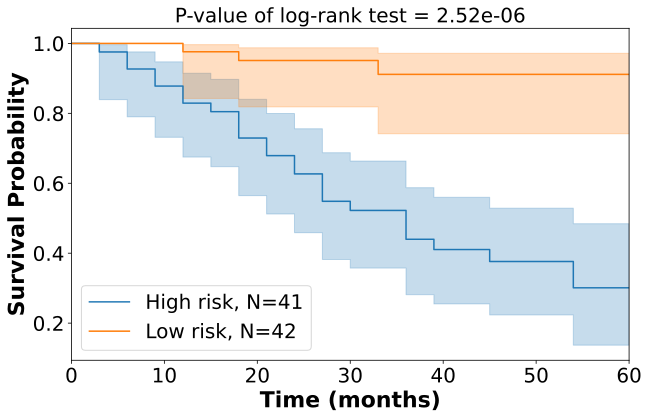

In [4]:

# HCC
def plot_KM_curves(risk, prefix, survival_time, survival_status, interval,dataset = "Gao"):
    """
    Survival analysis for model
    """
    median_risk = np.median(risk)
    print(f"median risk:{median_risk}")
    high_risk_group = risk > median_risk
    low_risk_group = risk <= median_risk
    T_high = survival_time[high_risk_group]
    T_low = survival_time[low_risk_group]
    E_high = survival_status[high_risk_group]
    E_low = survival_status[low_risk_group]
    results = logrank_test(T_high, T_low, event_observed_A=E_high, event_observed_B=E_low)
    # 输出p值
    print(f" Log-rank p-value: {results.p_value}")
    print(f"Plotting survival curve ")
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()
    plt.figure(figsize=(10, 6), dpi=300)
    T_high *=(interval/30)
    T_low *=(interval/30)
    T_high[T_high > 60] = 60
    kmf_high.fit(T_high, event_observed=E_high, label=f'High risk, N={len(T_high)}')
    kmf_low.fit(T_low, event_observed=E_low, label=f'Low risk, N={len(T_low)}')
    kmf_high.plot_survival_function(fontsize=fs_base)
    kmf_low.plot_survival_function(fontsize=fs_base)
    plt.legend(fontsize=fs_base)
    plt.title(f"P-value of log-rank test = {results.p_value:.2e}",fontsize = fs_base)
    plt.xlabel("Time (months)",fontsize=fs_base+2,weight='bold')
    plt.xlim(0, 60)
    plt.ylabel("Survival Probability",fontsize=fs_base+2,weight='bold')
    plt.show()

expr_tensor = torch.tensor(df_test.iloc[:,:-2].values,dtype=torch.float32).cuda()
risks = torch.cumsum(model.predict(expr_tensor),1).sum(1).cpu().detach().numpy()
median_risk = np.median(risks)
pats_high =df_test.index[risks>median_risk]
pats_low = df_test.index[risks<=median_risk]
print("High risk group size:",pats_high.shape[0],"Low risk group size:",pats_low.shape[0])
plot_KM_curves(risks,"",  df_test.values[:,-2], df_test.values[:,-1], 90,dataset ="")



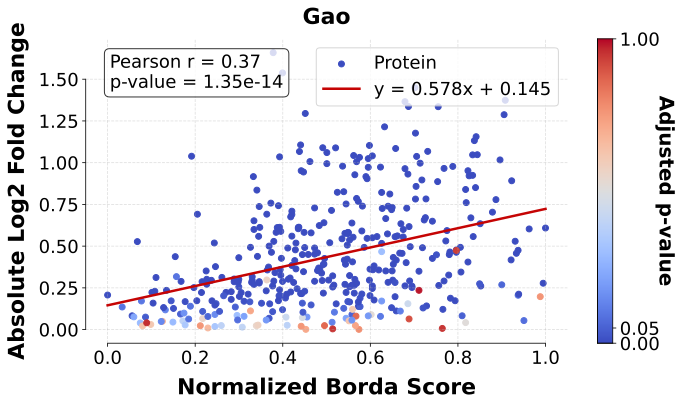

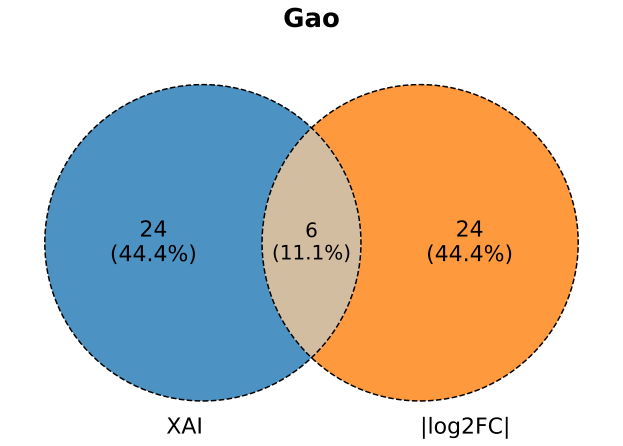

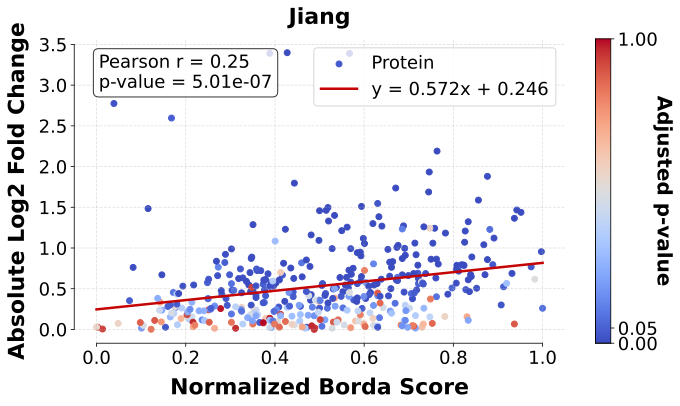

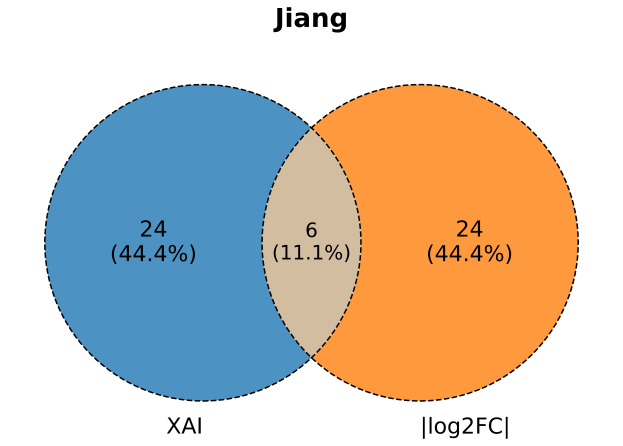

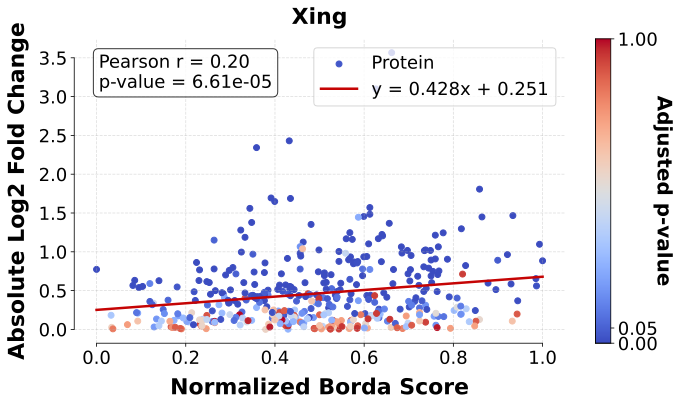

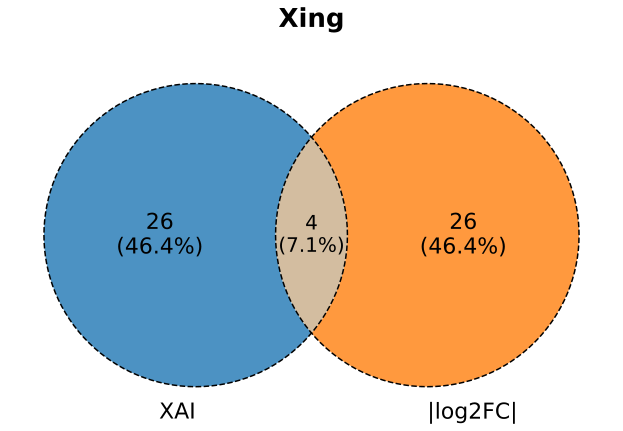

{'Gao': {'Top_DA': ['ENSG00000197561', 'ENSG00000180432', 'ENSG00000012223', 'ENSG00000113790', 'ENSG00000005381', 'ENSG00000183044', 'ENSG00000036473', 'ENSG00000172232', 'ENSG00000132837', 'ENSG00000100003', 'ENSG00000066813', 'ENSG00000161533', 'ENSG00000183747', 'ENSG00000171234', 'ENSG00000104738', 'ENSG00000100197', 'ENSG00000147576', 'ENSG00000172955', 'ENSG00000105852', 'ENSG00000165140', 'ENSG00000076003', 'ENSG00000112294', 'ENSG00000101323', 'ENSG00000100116', 'ENSG00000159228', 'ENSG00000197444', 'ENSG00000132840', 'ENSG00000138356', 'ENSG00000166508', 'ENSG00000117594'], 'Top_XAI': ['ENSG00000094916', 'ENSG00000116478', 'ENSG00000164692', 'ENSG00000079462', 'ENSG00000166337', 'ENSG00000166797', 'ENSG00000171723', 'ENSG00000137309', 'ENSG00000166130', 'ENSG00000215845', 'ENSG00000060971', 'ENSG00000284194', 'ENSG00000113790', 'ENSG00000132837', 'ENSG00000146729', 'ENSG00000100297', 'ENSG00000128928', 'ENSG00000128284', 'ENSG00000103549', 'ENSG00000099260', 'ENSG00000001630'

In [7]:
def minmax_norm(data):
    return (data - data.min()) / (data.max() - data.min())

cohorts = ['Gao','Jiang','Xing']
dfs_DA = []
dic_XAI_DA = {}
for i,cohort in enumerate(cohorts):
    ##  划分三种队列的高低风险人群
    fm = dfs[i]
    data_coh = data.loc[fm.index,:]
    data_out = data.loc[~data.index.isin(fm.index),:]
    expr_tensor = torch.tensor(data_coh.iloc[:,:-2].values,dtype=torch.float32).cuda()
    risks = torch.cumsum(model.predict(expr_tensor),1).sum(1).cpu().detach().numpy()
    median_risk = np.median(risks)
    pats_high =data_coh.index[risks>median_risk]
    pats_low = data_coh.index[risks<=median_risk]

    fm_nafilt = fm.loc[:,(fm.isna().sum(axis=0)/fm.shape[0])<0.5]
    imputer = KNNImputer(n_neighbors=10)
    # impute missing values
    imputed_data = imputer.fit_transform(fm_nafilt)
    # convert to pandas dataframe
    imputed_df = pd.DataFrame(imputed_data, columns=fm_nafilt.columns, index=fm_nafilt.index)
    # imputed_df
    # 计算XAI
    model_interpreter = Interpreter(model, data_coh.iloc[:,:-2].values)
    # data_train
    baseline = torch.mean(torch.Tensor(data_out.iloc[:,:-2].values).cuda(), dim=0)
    node_borda, hyperedge_borda = model_interpreter.all_borda_rank(model.hgc_encoder[0], baselineTensor=baseline,IGsteps=8)#GSsamples=32
    XAI_coh = {"XAI_scores": list(node_borda),"proteins": list(data_coh.columns[:-2]),}
    
    # 差异分析
    df_DA=Difference_Analysis(pats_high, pats_low,imputed_df,XAI_coh)
    dfs_DA.append(df_DA)
    # print(df_DA['adj_p'].min())
    # 画图
    dict_XAI_DA = pd.DataFrame({
        '|log2FC|': df_DA['|log2FC|'],
        'XAI_score': minmax_norm(df_DA['XAI']),
        'adj_p': df_DA['adj_p'],
    })
    plot_scatter_regression(dict_XAI_DA,fs_base,title=cohort)

    topn = 30

    # 获取前 n DA Protein
    Top_DA = df_DA.sort_values(by='|log2FC|', ascending=False).head(topn)['Protein'].to_list()

    # 获取前 n XAI Protein
    Top_XAI = df_DA.sort_values(by='XAI', ascending=False).head(topn)['Protein'].to_list()
    dic_XAI_DA[cohort] = {"Top_DA": Top_DA, "Top_XAI": Top_XAI}
    set_XAI = set(Top_XAI)
    set_DA = set(Top_DA)

    draw_venn(sets=[set_XAI, set_DA],
                labels=(" XAI", "|log2FC|"),
                title=f"{cohort}",
                # colors=("#0099ff", "#ff0000"),
                alpha=0.8,
                show_percentages=True,
                figsize=(9, 7),subset_label_fontsize=fs_base+2)    
print(dic_XAI_DA)

In [15]:

dic_XAI_DA
# save dic in txt
with open("dic_XAI_DA.txt", "w") as f:
    for cohort, proteins in dic_XAI_DA.items():
        f.write(f"{cohort}: {proteins}\n")

In [10]:
dic_XAI_DA
# 计算交集
for cohort in dic_XAI_DA.keys():
    Top_DA = dic_XAI_DA[cohort]["Top_DA"]
    Top_XAI = dic_XAI_DA[cohort]["Top_XAI"]
    set_XAI = set(Top_XAI)
    set_DA = set(Top_DA)
    intersection = set_XAI.intersection(set_DA)
    print(f"{cohort} intersection ({len(intersection)}): {intersection}")

Gao intersection (6): {'ENSG00000161533', 'ENSG00000101323', 'ENSG00000183747', 'ENSG00000132837', 'ENSG00000113790', 'ENSG00000112294'}
Jiang intersection (6): {'ENSG00000073169', 'ENSG00000079462', 'ENSG00000103549', 'ENSG00000100297', 'ENSG00000132837', 'ENSG00000146729'}
Xing intersection (4): {'ENSG00000132837', 'ENSG00000113790', 'ENSG00000137309', 'ENSG00000152952'}


# Evolution Reg

In [17]:
import collections
from openai import OpenAI
from pydantic import BaseModel, Field
import requests
from typing import Literal
import os
import tiktoken
import json
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

client = OpenAI(api_key="", 
                base_url="")
SYSTEM_PROMPT = """
You are an AI assistant specialized in evaluating scientific hypotheses in cancer bioinformatics. Your primary goal is to meticulously evaluate hypotheses regarding gene-pathway-cancer relationships across five dimensions: Richness, Relevance, Clarity, Feasibility, and Significance.

## Evaluation Context
For a comprehensive assessment, refer to:
1. Gene-Pathway-Cancer relationship context
2. Supporting statistical evidence

## Evaluation Protocol
Execute evaluation in these steps:
1. Analyze the hypothesis in the context of biological plausibility and novelty
2. Evaluate each dimension using the criteria below
3. Provide concrete suggestions for improvement
4. Assign scores on 0-100 scale with a discerning and critical evaluation (avoid a tendency towards uniformly high ratings (80-100) unless fully justified)

## Evaluation Criteria
### Richness (1-100)
- The scientific hypothesis contains enough information so as not to leave the reader in doubt
- Logical chain completeness

### Relevance (1-100)
- Statistical association strength (p-value/HR ...)
- The relevance of the scientific hypothesis to the specified gene, pathway, or cancer (if it is not statistically significant, it can be ignored)

### Clarity (1-100)
- Precise mechanistic description
- Unambiguous terminology
- Molecular interactions specificity

### Feasibility (1-100)
- Feasibility of technical verification of causal relationships of scientific hypotheses
- Biological plausibility

### Significance (1-100)
- Assess the potential impact of the hypothesis on the field
- Consider novelty, potential for clinical translation, and whether it could lead to paradigm shifts

## Output Format
Strictly output JSON format:
{
  "Hypothesis": "Original hypothesis text",
  "AllScores": {
    "Richness": {"score": 0, "rationale": "", "suggestion": ""},
    "Relevance": {"score": 0, "rationale": "", "suggestion": ""},
    "Clarity": {"score": 0, "rationale": "", "suggestion": ""},
    "Feasibility": {"score": 0, "rationale": "", "suggestion": ""},
    "Significance": {"score": 0, "rationale": "", "suggestion": ""}
  },
  "overall_score": 0.0,
}
"""

from pydantic import BaseModel, Field

class DimensionScore(BaseModel):
    score: int = Field(
        default=0,
        # description="Score on 1-5 Likert scale",
        json_schema_extra={"json_alias": "score"}
    )
    rationale: str = Field(
        default="",
        description="Rationale for the score",
        json_schema_extra={"json_alias": "rationale"}
    )
    suggestion: str = Field(
        default="",
        description="Suggestion for improvement",
        json_schema_extra={"json_alias": "suggestion"}
    )

class Scores(BaseModel):
    Richness: DimensionScore = Field(
        default_factory=DimensionScore,
        description="Richness score and rationale",
        json_schema_extra={"json_alias": "Richness"}
    )
    Relevance: DimensionScore = Field(
        default_factory=DimensionScore,
        description="Relevance score and rationale",
        json_schema_extra={"json_alias": "Relevance"}
    )
    Clarity: DimensionScore = Field(
        default_factory=DimensionScore,
        description="Clarity score and rationale",
        json_schema_extra={"json_alias": "Clarity"}
    )
    Feasibility: DimensionScore = Field(
        default_factory=DimensionScore,
        description="Feasibility score and rationale",
        json_schema_extra={"json_alias": "Feasibility"}
    )
    Significance: DimensionScore = Field(  # 添加了suggestion字段
        default_factory=DimensionScore,
        description="Significance score and rationale",
        json_schema_extra={"json_alias": "Significance"}
    )

class Evaluation(BaseModel):
    Hypothesis: str = Field(
        default="",
        description="Original hypothesis text",
        json_schema_extra={"json_alias": "hypothesis"}
    )
    AllScores: Scores = Field(  # 首字母大写的Scores
        default_factory=Scores,
        description="Scores for each dimension",
        json_schema_extra={"json_alias": "Scores"}
    )
    overall_score: float = Field(
        default=0.0,
        # description="Overall score on 1-5 Likert scale",
        json_schema_extra={"json_alias": "overall_score"}
    )

def generate_user_prompt(context):
    c = context.copy()
    c.pop('hypothesis')
    user = f"""
## Biological Context
{c}

## Hypothesis to Evaluate
{context['hypothesis']}

Perform comprehensive evaluation and output in required JSON format.
"""
    return user


# 评估函数
def evaluate_hypothesis(context):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": generate_user_prompt(context)}
    ]
    
    response = client.beta.chat.completions.parse(
        # model="gpt-4-turbo",
        model="chatgpt-4o-latest",
        messages=messages,
        temperature=0,
        # max_tokens=1500,
        response_format = Evaluation,
    )
    
    # # 提取JSON输出
    # try:
    #     return json.loads(response.choices[0].message.content)
    # except:
    #     print("Error parsing JSON response")
    #     return response.choices[0].message.content
    message = response.choices[0].message.parsed
    return message

def create_hypcontext(context,hyp):
    tc = context.copy()
    tc.pop([k for k in context.keys() if "XAI" in k][0])
    tc.update({"hypothesis":hyp['Hypothesis'],})
    return tc
def evaluate_hyp(context,hyp):
    hypcontext = create_hypcontext(context,hyp)
    return evaluate_hypothesis(hypcontext)


def plot_evolution(data,ymin,ymax,title = "Evolution on Hypothesis",score_name = "Score"):
    """
    绘制进化轮次得分回归图（类似于图2c）
    
    参数:
    data : list of lists
        包含10组得分的列表，每组为[score0, score1, score2, score3]
        对应进化轮次0-3
        
    返回:
    matplotlib Figure 对象
    """
    # # 设置图形和子图
    # fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)
    # titles = [
    #     "Evolution on DREAM questions",
    #     "Evolution on GPT-4 questions",
    #     "Evolution on graduate student questions"
    # ]
    
    # 轮次定义
    rounds = np.array([0, 1, 2, 3])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 绘制每组数据的相邻间隔进化线
    
    scores = np.array(data)
    
    # 1. 绘制每组数据的相邻间隔进化线
    for group in scores:
        # 绘制每个相邻间隔的连线
        for i in range(3):
            ax.plot([rounds[i], rounds[i+1]], 
                    [group[i], group[i+1]], 
                    'b-', alpha=0.3, linewidth=1)
    
    # 2. 计算所有散点的总回归线和95%置信区间
    # 准备数据 (40个点: 10组 * 4轮次)
    x_all = np.repeat(rounds, len(scores))  # [0,0,0...1,1,1...]
    y_all = scores.flatten('F')  # 按列展平
    
    # 添加常数项用于线性回归
    X = sm.add_constant(x_all)
    model = sm.OLS(y_all, X).fit()
    
    # 获取回归线的参数
    intercept, slope = model.params
    p_value = model.f_pvalue  # 回归的p值
    
    # 生成用于绘图的连续x值
    x_pred = np.linspace(0, 3, 100)
    X_pred = sm.add_constant(x_pred)
    
    # 计算预测值和置信区间
    pred = model.get_prediction(X_pred)
    pred_mean = pred.predicted_mean
    pred_ci = pred.conf_int(alpha=0.05)  # 95% CI
    
    # 绘制总回归线
    ax.plot(x_pred, pred_mean, 'r-', linewidth=2, label='Linear Regression')
    
    # 绘制95%置信区间
    ax.fill_between(x_pred, pred_ci[:, 0], pred_ci[:, 1], 
                    color='r', alpha=0.2, label='95% Confidence Interval')
    
    # 添加统计信息 (β系数和p值)
    # 使用科学计数法格式化p值
    if p_value < 0.001:
        p_text = f"{p_value:.2e}"
    else:
        p_text = f"{p_value:.4f}"
    
    # text 加入外边框
    stats_text = f"$\\beta={slope:.4f}$\n($p={p_text}$)"
    ax.text(0.80, 0.05, stats_text,
            transform=ax.transAxes, 
            horizontalalignment='center',
            bbox=dict(
            boxstyle='round,pad=0.3',  # 圆角矩形，带内边距
            facecolor='white',         # 填充色
            edgecolor='gray',          # 边框颜色
            alpha=0.7,                 # 透明度
            linewidth=1                # 边框线宽
            ),
            fontsize=fs_base)
    
    # 设置子图属性
    # ax.set_title(title)
    ax.set_ylabel(score_name,fontsize=fs_base+2,weight='bold')
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(-0.1, 3.1)
    ax.set_xticks(rounds)
    ax.set_xticklabels(['0', '1', '2', '3'])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    ax.legend(loc='upper left',fontsize=fs_base)
    
    # 设置公共x轴标签
    fig.text(0.5, 0.01, 'Competition Rounds', ha='center', fontsize=fs_base+2,weight='bold')
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    # plt.savefig(f"./{title}.svg",dpi=300,format = 'svg')

    return fig

    # hyp['Hypothesis']

def process_evals_dims(evals):
    # dims = list(list(list(evals.values())[0].values())[0]['AllScores'].keys())
    reg_dict = collections.defaultdict(list)
    for gene,scores in evals.items():
        dims_dict=collections.defaultdict(list)
        for _,s_iter in scores.items():
            for dim,score in s_iter['AllScores'].items():
                dims_dict[dim].append(score['score'])
        for dim in dims_dict.keys():
            reg_dict[dim].append(dims_dict[dim])

    return reg_dict
def process_evals_mean(evals):
    # dims = list(list(list(evals.values())[0].values())[0]['AllScores'].keys())
    reg_dict = collections.defaultdict(list)

    for gene,scores in evals.items():
        reg_o = []# overall
        reg_m = []# mean
        for _,s_iter in scores.items():
            reg_o.append(s_iter['overall_score'])
            s_m = 0
            for dim,score in s_iter['AllScores'].items():
                s_m += score['score']
            s_m /= len(s_iter['AllScores'])
            reg_m.append(s_m)
        reg_dict['score_overall'].append(reg_o)
        reg_dict['score_mean'].append(reg_m)
    return reg_dict

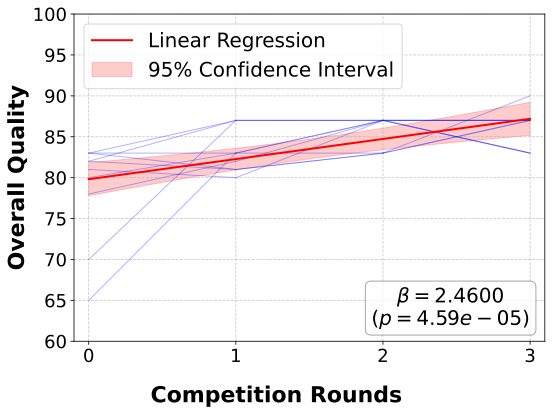

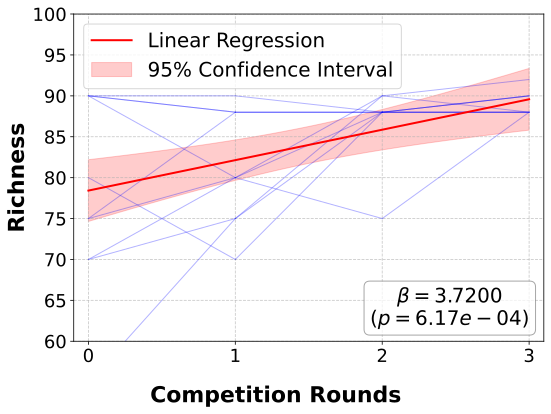

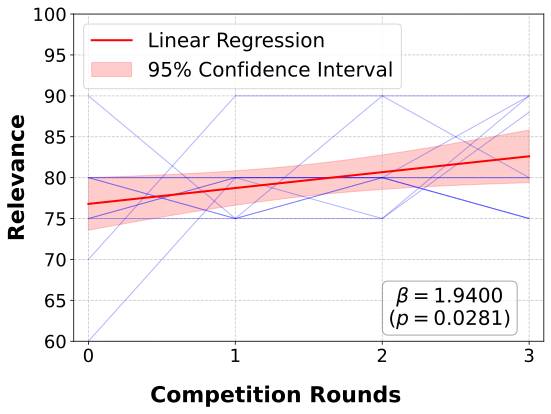

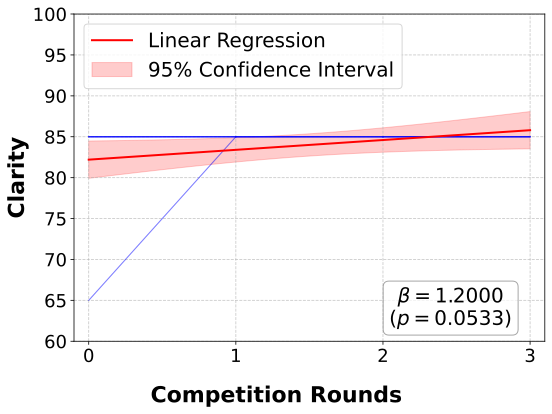

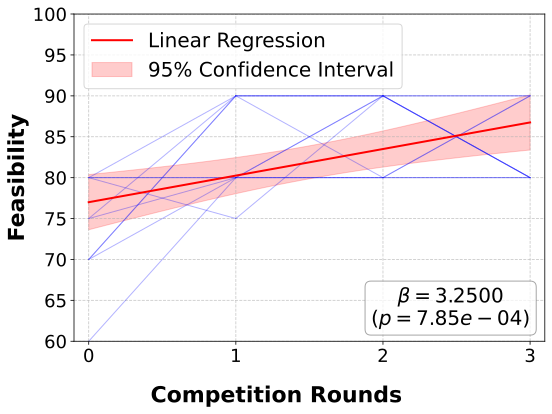

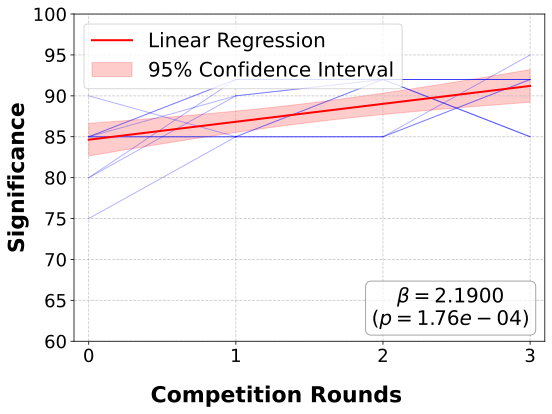

In [18]:
path_tri = "data/Triplets/"
fn_evals = f"{path_tri}Evolution_evals.json"
if not os.path.exists(fn_evals):
    # 三元组统计信息
    fn_tri = f"{path_tri}/10triplets_statistics.json"
    evals = collections.defaultdict(dict)

    with open(fn_tri, "r") as f:
        tripls = json.load(f)

    for context in tripls.values():
        gene=context['gene name']
        name_hyp = f"liver neoplasm_{gene}_8"
        path_champ = f"{path_tri}{name_hyp}/round3/evolved_hypotheses"
        cham_js = os.listdir(path_champ)[0]
        # ini generate js
        path_ini =f"{path_tri}liver neoplasm_SF3B2_8/generate_hypotheses"
        with open(os.path.join(path_ini, cham_js), "r") as f:
            hyp = json.load(f)
        evals[f'{gene}'][f'hyp0'] =  json.loads(evaluate_hyp(context,hyp).model_dump_json())
        # 迭代所有evolved_hypotheses文件
        for i in range(1,4):
            path = f"{path_tri}{name_hyp}/round{i}/evolved_hypotheses"
            with open(os.path.join(path, cham_js), "r") as f:
                hyp = json.load(f)
            evals[f'{gene}'][f'hyp{i}'] =  json.loads(evaluate_hyp(context,hyp).model_dump_json())
    with open(fn_evals, "w") as f:
        json.dump(evals, f, indent=4)
else:
    with open(fn_evals, "r") as f:
        evals = json.load(f)

reg_mean_dict = process_evals_mean(evals)
fig = plot_evolution(reg_mean_dict['score_mean'],60,100,score_name = "Overall Quality",title=f"Quality by Overall Quality")
plt.show()

reg_dims_dict = process_evals_dims(evals)
for dim in reg_dims_dict.keys():
    fig = plot_evolution(reg_dims_dict[dim],60,100,score_name = dim,title=f"Quality by {dim}")
    plt.show()

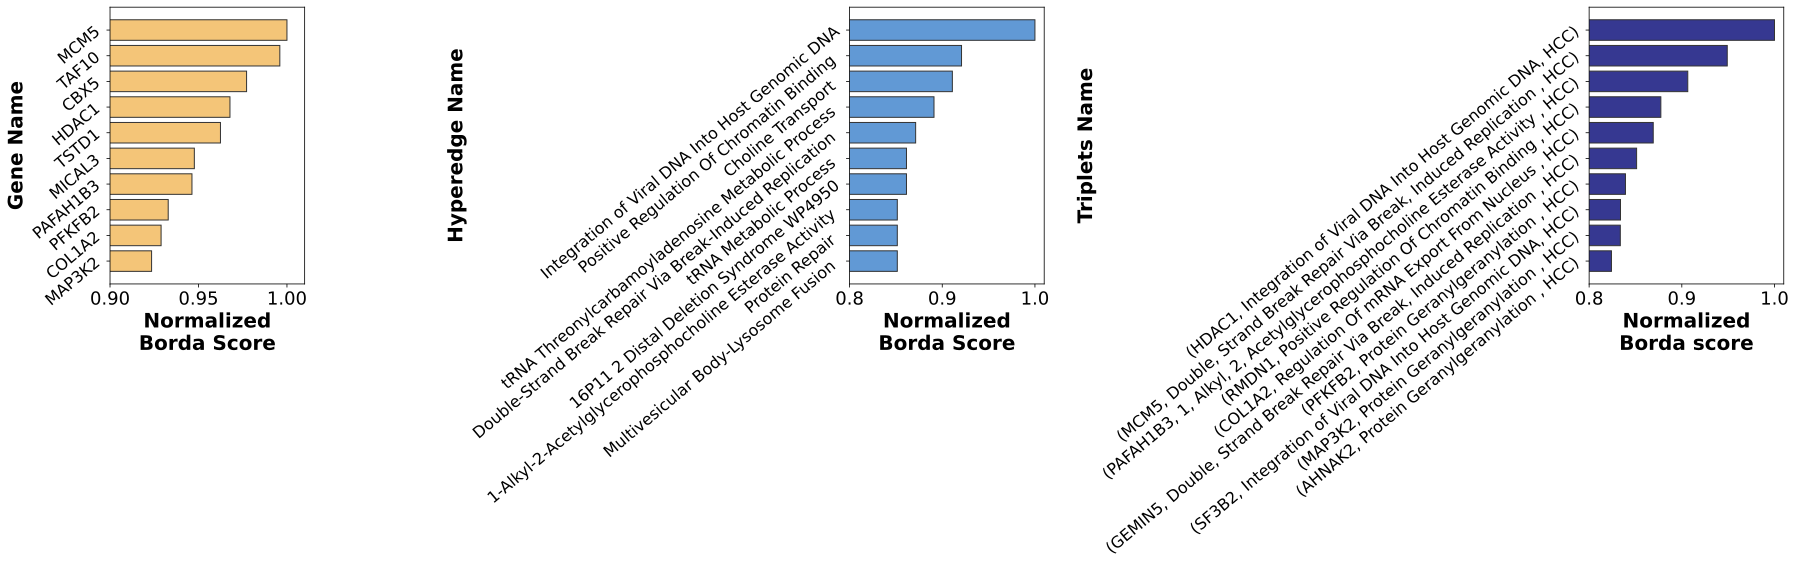

In [19]:

fn_borda = "data/Triplets/bordas_dict.json"

def minmax(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))

with open(fn_borda, 'r') as f:
    bordas_dict = json.load(f)# test

# hyperedge 去除()及其中的元素
bordas_dict['hyperedge_name'] = [i.split("(")[0]+i.split(")")[1] if "("in i else i for i in bordas_dict['hyperedge_name']]
# 去除pair_name中存在'['的元素, 同时删除pair_borda对应索引的元素(即超边中只含有一个基因的情况)
list_index = []
for i in range(len(bordas_dict['pair_name'])):
    if '[' in bordas_dict['pair_name'][i]:
        # print(i, bordas_dict['pair_name'][i], bordas_dict['pair_borda'][i])
        list_index.append(i)
for i in list_index[::-1]:
    bordas_dict['pair_name'].pop(i)
    bordas_dict['pair_borda'].pop(i)
# print(bordas_dict['pair_name'])
# print(bordas_dict['pair_borda'])
# 对list_pn(list)中的所有元素(str)执行（保存回原来的list）：将第一个出现的'-'改成', ';并在末尾加上', HCC'
for i in range(len(bordas_dict['pair_name'])):
    if '-' in bordas_dict['pair_name'][i]:
        bordas_dict['pair_name'][i] = bordas_dict['pair_name'][i].replace('-', ', ')
    if '(' in bordas_dict['pair_name'][i]:
        # bordas_dict['pair_name'][i] = bordas_dict['pair_name'][i].replace('(', '[')
        # bordas_dict['pair_name'][i] = bordas_dict['pair_name'][i].replace(')', ']')
        # 删除()及其中元素
        bordas_dict['pair_name'][i] = bordas_dict['pair_name'][i].split("(")[0]+bordas_dict['pair_name'][i].split(")")[1]

    bordas_dict['pair_name'][i] += ', HCC)'
    bordas_dict['pair_name'][i] = '(' + bordas_dict['pair_name'][i]

# bordas_dict['pair_name']
# 设置整个图形的尺寸和分辨率
plt.figure(figsize=(30, 5), dpi=300) 
# 创建1行3列的子图布局
gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=2.8)  # wspace控制子图之间的横向间距
node_c = "#F1B656"
hype_c = '#397FCB'
triplet_c = '#040676'
axmin = 0.8
axmax = 1.01
# 通用设置
alpha = 0.8
edgecolor = "black"
rotation = 40
# 第一子图：Top 10 Node Borda Score
ax1 = plt.subplot(gs[0])
node_borda = bordas_dict['node_borda']
top10_node_borda = minmax(sorted(bordas_dict['node_borda'], reverse=True))[:10]
top10_node_name = [bordas_dict['node_name'][i] for i in np.argsort(bordas_dict['node_borda'])[::-1][:10]]
x = top10_node_borda
y = top10_node_name
ax1.barh(y, x, color=node_c, alpha=alpha, edgecolor=edgecolor)
ax1.set_xlim(0.9, axmax)
ax1.set_xlabel('Normalized\nBorda Score', fontsize=fs_base, fontweight='bold')
ax1.set_ylabel('Gene Name', fontsize=fs_base, fontweight='bold')
# ax1.tick_params(axis='x', rotation=rotation,right = True)
plt.yticks(rotation=rotation,ha='right',fontsize=fs_base-4)
# ax1.set_title('Top 10 Node Borda Score', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  

# 第二子图：Top 10 Hyperedge Borda Score
ax2 = plt.subplot(gs[1])
df_he = pd.DataFrame({
    'hyperedge_borda': minmax(bordas_dict['hyperedge_borda']),
    'hyperedge_name': bordas_dict['hyperedge_name']
})
df_he.sort_values('hyperedge_borda', ascending=False, inplace=True)
df_he10 = df_he.loc[[isinstance(hn, str) for hn in df_he['hyperedge_name']], :][:10]

y = df_he10['hyperedge_name']
x = df_he10['hyperedge_borda']
ax2.barh(y, x, color=hype_c, alpha=alpha, edgecolor=edgecolor)
ax2.set_xlim(axmin, axmax)
ax2.set_xlabel('Normalized\nBorda Score', fontsize=fs_base, fontweight='bold')
ax2.set_ylabel('Hyperedge Name', fontsize=fs_base, fontweight='bold')
# ax2.set_title('Top 10 Hyperedge Borda Score', fontsize=16, fontweight='bold')
# ax2.tick_params(axis='x', rotation=rotation,right = True)
plt.yticks(rotation=rotation,ha='right',fontsize=fs_base-4)
plt.gca().invert_yaxis()  

# 第三子图：Top 10 Triplets Borda Score
ax3 = plt.subplot(gs[2])
top10_pair_borda = minmax(bordas_dict['pair_borda'])[:10]
top10_pair_name = bordas_dict['pair_name'][:10]
x = top10_pair_borda
y = top10_pair_name
ax3.barh(y, x, color=triplet_c, alpha=alpha, edgecolor=edgecolor)
ax3.set_xlim(axmin, axmax)
ax3.set_xlabel('Normalized\nBorda score', fontsize=fs_base, fontweight='bold')
ax3.set_ylabel('Triplets Name', fontsize=fs_base, fontweight='bold')
# ax3.set_title('Top 10 Triplets Borda Score', fontsize=16, fontweight='bold')
# ax3.tick_params(axis='x', rotation=rotation,right = True)
plt.yticks(rotation=rotation,ha='right',fontsize=fs_base-4)

# ax3.spines['top'].set_visible(False)
# ax3.spines['right'].set_visible(False)
plt.gca().invert_yaxis()  

# 调整整体布局
plt.tight_layout()
plt.show()

# 双向扰动实验

In [22]:
from utils.Borda_Score_validator import *
from utils.Interpret import *
path_res = f"Results/XAI_dual_dir_val/"
def	get_borda_score_10seeds(HD,PK_D,dataset,data):
	td_h_10s,td_n_10s,bu_h_10s,bu_n_10s = [],[],[],[]
	for seed in range(10):
		if PK_D['type_know']!='Reactome':
			data_train,data_valid,data_test,t_obs,H_df = data_split(seed=seed,dataset=dataset,data=data,HD=PK_D,construct_H=True,H_df=True)
		else:
			data_train,data_valid,data_test,t_obs = data_split(seed=seed,dataset=dataset,data=data,HD=PK_D,construct_H=False)
		H = H_df.values
		G = generate_G_from_H(H.T) if HD["edge_pooling"] else generate_G_from_H(H)
		logger.info(f"H:{H.shape}; data:{data.shape}; G:{G.shape}; t_obs:{t_obs}")
		logger.info(f"{dataset} Best Paras-{seed}:L2{HD['l2']};lr{HD['lr']};glr{HD['glr']};agg{HD['AGG']};ph{HD['predict_hiddens']}")				
		HD['pooling_hiddens']=build_hiddens(H.shape[1],PK_D['divisor'])
		logger.info(f"Pooling_hiddens:{HD['pooling_hiddens']}\n")
		fn_ckpt = f"{path_res}/seed{seed}"  
		os.makedirs(f"{path_res}/", exist_ok=True)
		# 由于计算borda score需要用到模型层结构信息，因此需要初始化模型
		model = HGS_Interpret(HD,data_train=data_train,data_eval=data_valid,data_test = data_test,H=H,fn_ckpt=fn_ckpt,t_obs=t_obs,G=G,seed=seed)
		model = model.cuda()
		optimizer = optim.Adam(model.parameters(), lr=HD['lr'],weight_decay=HD['l2'])
		model = model.fit(optimizer=optimizer,logger=logger,num_epochs=HD["epochs"],batch_size=HD["batch_size"],loss_dict=HD['loss_w'])
		(top_remove_ci_h,bottom_remove_ci_h),(top_remove_ci_n,bottom_remove_ci_n),percent_space=\
			borda_score_validation(model,data_base=data_train,data_test=data_test,H=H,seed=seed)
		td_h_10s.append(top_remove_ci_h)
		td_n_10s.append(top_remove_ci_n)
		bu_h_10s.append(bottom_remove_ci_h)
		bu_n_10s.append(bottom_remove_ci_n)
	td_h,td_n,bu_h,bu_n = np.array(td_h_10s).mean(axis=0),np.array(td_n_10s).mean(axis=0),np.array(bu_h_10s).mean(axis=0),np.array(bu_n_10s).mean(axis=0)
	plot_bs_validation("10mean",percent_space,td_h,bu_h,percent_space,td_n,bu_n)
	return td_h_10s,td_n_10s,bu_h_10s,bu_n_10s


def borda_score_validation(model,data_base,data_test,H,seed):
	# 计算borda score
	model_interpreter = Interpreter(model, data_test[:, :-2])
	## 使用训练集的平均值作为baseline
	baseline = torch.mean(torch.Tensor(data_base[:, :-2]).cuda(), dim=0)
	node_borda, hyperedge_borda = model_interpreter.all_borda_rank(model.hgc_encoder[0], baselineTensor=baseline,IGsteps=50)#GSsamples=32
	# Borda Score Validate
	percent_space_h, top_remove_ci_h, bottom_remove_ci_h = validate_hyperedge_borda_scores(data_test, hyperedge_borda, H, 0.5, model, method='baseline')
	percent_space_n, top_remove_ci_n, bottom_remove_ci_n = validate_node_borda_scores(data_test, node_borda, H, 0.5, model, method='baseline')
	plot_bs_validation(seed,percent_space_h,top_remove_ci_h,bottom_remove_ci_h,percent_space_n,top_remove_ci_n,bottom_remove_ci_n)
	return (top_remove_ci_h,bottom_remove_ci_h),(top_remove_ci_n,bottom_remove_ci_n),percent_space_n
def plot_bs_validation(seed,percent_space_h,top_remove_ci_h,bottom_remove_ci_h,percent_space_n,top_remove_ci_n,bottom_remove_ci_n):
	# plot 画出网格 并且将折现的点画出来
	fig, ax = plt.subplots(1, 2, figsize=(10, 5))
	ax[0].plot(percent_space_h, top_remove_ci_h, label='Top-down masking', marker='o')  # 使用 'o' 标记点
	ax[0].plot(percent_space_h, bottom_remove_ci_h, label='Bottom-up masking', marker='o')  # 使用 'o' 标记点
	ax[0].set_xlabel('Percentage of masked edges',fontsize=16,weight='bold')
	ax[0].set_ylabel('C-index',fontsize=16,weight='bold')
	# ax[0].set_title('Hyperedge Borda Score',fontsize=16)
	ax[0].legend(fontsize=14)
	ax[0].grid(True)  # 添加网格


	ax[1].plot(percent_space_n, top_remove_ci_n, label='Top-down masking', marker='o')  # 使用 'o' 标记点
	ax[1].plot(percent_space_n, bottom_remove_ci_n, label='Bottom-up masking', marker='o')  # 使用 'o' 标记点
	ax[1].set_xlabel('Percentage of masked nodes',fontsize=16,weight='bold')
	ax[1].set_ylabel('C-index',fontsize=16,weight='bold')
	# ax[1].set_title('Node Borda Score',fontsize=16,weight='bold')
	ax[1].legend(fontsize=14)
	ax[1].grid(True)  # 添加网格

	plt.tight_layout()
	# plt.savefig(f'borda_scores/borda_score_validate_10seedsmean-5910.png')
	# plt.savefig(f'borda_scores/borda_score_validate_seed{seed}-5910.svg',format='svg')


2025-12-02 14:45:32,636 - utils.Interpret - INFO - H:(400, 59); data:(412, 402); G:(59, 59); t_obs:44.0
2025-12-02 14:45:32,637 - utils.Interpret - INFO - HCC Best Paras-0:L20.1;lr0.01;glr0;aggcat;ph[200, 100]
2025-12-02 14:45:32,638 - utils.Interpret - INFO - Pooling_hiddens:[59, 5]



Hyperedges computed by Pearson-Hcluster= 59


2025-12-02 14:45:32,923 - utils.Interpret - INFO - --------------------
2025-12-02 14:45:32,924 - utils.Interpret - INFO - Epoch 0/50
2025-12-02 14:45:33,129 - utils.Interpret - INFO - Updating eval ci: 0.579104; eval loss: 53.960564
2025-12-02 14:45:35,699 - utils.Interpret - INFO - --------------------
2025-12-02 14:45:35,701 - utils.Interpret - INFO - Epoch 10/50
2025-12-02 14:45:35,913 - utils.Interpret - INFO - Updating eval ci: 0.722985; eval loss: 56.039520
2025-12-02 14:45:38,750 - utils.Interpret - INFO - --------------------
2025-12-02 14:45:38,752 - utils.Interpret - INFO - Epoch 20/50
2025-12-02 14:45:38,982 - utils.Interpret - INFO - Updating eval ci: 0.721791; eval loss: 53.243671
2025-12-02 14:45:41,923 - utils.Interpret - INFO - --------------------
2025-12-02 14:45:41,924 - utils.Interpret - INFO - Epoch 30/50
2025-12-02 14:45:42,152 - utils.Interpret - INFO - Updating eval ci: 0.716418; eval loss: 53.455635
2025-12-02 14:45:45,186 - utils.Interpret - INFO - ----------

Top 0 hyperedges removed, test CI: 0.6930881420418517
Bottom 0 hyperedges removed, test CI: 0.6930881420418517
Top 5 hyperedges removed, test CI: 0.6816740646797718
Bottom 5 hyperedges removed, test CI: 0.6873811033608117
Top 11 hyperedges removed, test CI: 0.6981610653138871
Bottom 11 hyperedges removed, test CI: 0.6886493341788206
Top 17 hyperedges removed, test CI: 0.6867469879518072
Bottom 17 hyperedges removed, test CI: 0.6949904882688649
Top 23 hyperedges removed, test CI: 0.6785034876347495
Bottom 23 hyperedges removed, test CI: 0.6930881420418517
Top 29 hyperedges removed, test CI: 0.6544071020925808
Bottom 29 hyperedges removed, test CI: 0.6981610653138871
Top 0 nodes removed, test CI: 0.6930881420418517
Bottom 0 nodes removed, test CI: 0.6930881420418517
Top 40 nodes removed, test CI: 0.6975269499048827
Bottom 40 nodes removed, test CI: 0.6918199112238428
Top 80 nodes removed, test CI: 0.689283449587825
Bottom 80 nodes removed, test CI: 0.6918199112238428
Top 120 nodes remove

2025-12-02 14:45:54,387 - utils.Interpret - INFO - H:(400, 59); data:(412, 402); G:(59, 59); t_obs:44.0
2025-12-02 14:45:54,388 - utils.Interpret - INFO - HCC Best Paras-1:L20.1;lr0.01;glr0;aggcat;ph[200, 100]
2025-12-02 14:45:54,388 - utils.Interpret - INFO - Pooling_hiddens:[59, 5]



...

Top 0 hyperedges removed, test CI: 0.6786140979689367
Bottom 0 hyperedges removed, test CI: 0.6786140979689367
Top 5 hyperedges removed, test CI: 0.6816009557945042
Bottom 5 hyperedges removed, test CI: 0.6804062126642771
Top 11 hyperedges removed, test CI: 0.6887694145758662
Bottom 11 hyperedges removed, test CI: 0.6827956989247311
Top 17 hyperedges removed, test CI: 0.6857825567502986
Bottom 17 hyperedges removed, test CI: 0.6792114695340502
Top 23 hyperedges removed, test CI: 0.6606929510155317
Bottom 23 hyperedges removed, test CI: 0.6845878136200717
Top 29 hyperedges removed, test CI: 0.6577060931899642
Bottom 29 hyperedges removed, test CI: 0.6762246117084827
Top 0 nodes removed, test CI: 0.6786140979689367
Bottom 0 nodes removed, test CI: 0.6786140979689367
Top 40 nodes removed, test CI: 0.6589008363201911
Bottom 40 nodes removed, test CI: 0.6804062126642771
Top 80 nodes removed, test CI: 0.6445639187574671
Bottom 80 nodes removed, test CI: 0.6804062126642771
Top 120 nodes remov

2025-12-02 14:48:45,633 - utils.Interpret - INFO - H:(400, 59); data:(412, 402); G:(59, 59); t_obs:44.0
2025-12-02 14:48:45,633 - utils.Interpret - INFO - HCC Best Paras-9:L20.1;lr0.01;glr0;aggcat;ph[200, 100]
2025-12-02 14:48:45,634 - utils.Interpret - INFO - Pooling_hiddens:[59, 5]



Hyperedges computed by Pearson-Hcluster= 59


2025-12-02 14:48:45,876 - utils.Interpret - INFO - --------------------
2025-12-02 14:48:45,877 - utils.Interpret - INFO - Epoch 0/50
2025-12-02 14:48:46,076 - utils.Interpret - INFO - Updating eval ci: 0.443030; eval loss: 54.360096
2025-12-02 14:48:48,563 - utils.Interpret - INFO - --------------------
2025-12-02 14:48:48,564 - utils.Interpret - INFO - Epoch 10/50
2025-12-02 14:48:48,791 - utils.Interpret - INFO - Updating eval ci: 0.746667; eval loss: 52.880035
2025-12-02 14:48:51,767 - utils.Interpret - INFO - --------------------
2025-12-02 14:48:51,769 - utils.Interpret - INFO - Epoch 20/50
2025-12-02 14:48:51,993 - utils.Interpret - INFO - Updating eval ci: 0.743636; eval loss: 54.744965
2025-12-02 14:48:55,047 - utils.Interpret - INFO - --------------------
2025-12-02 14:48:55,049 - utils.Interpret - INFO - Epoch 30/50
2025-12-02 14:48:55,286 - utils.Interpret - INFO - Updating eval ci: 0.736364; eval loss: 53.120789
2025-12-02 14:48:58,167 - utils.Interpret - INFO - ----------

Top 0 hyperedges removed, test CI: 0.7245958429561201
Bottom 0 hyperedges removed, test CI: 0.7245958429561201
Top 5 hyperedges removed, test CI: 0.73094688221709
Bottom 5 hyperedges removed, test CI: 0.7176674364896074
Top 11 hyperedges removed, test CI: 0.7205542725173211
Bottom 11 hyperedges removed, test CI: 0.7107390300230947
Top 17 hyperedges removed, test CI: 0.6997690531177829
Bottom 17 hyperedges removed, test CI: 0.7113163972286374
Top 23 hyperedges removed, test CI: 0.6968822170900693
Bottom 23 hyperedges removed, test CI: 0.7130484988452656
Top 29 hyperedges removed, test CI: 0.6893764434180139
Bottom 29 hyperedges removed, test CI: 0.6968822170900693
Top 0 nodes removed, test CI: 0.7245958429561201
Bottom 0 nodes removed, test CI: 0.7245958429561201
Top 40 nodes removed, test CI: 0.7136258660508084
Bottom 40 nodes removed, test CI: 0.7303695150115473
Top 80 nodes removed, test CI: 0.680715935334873
Bottom 80 nodes removed, test CI: 0.7297921478060047
Top 120 nodes removed,

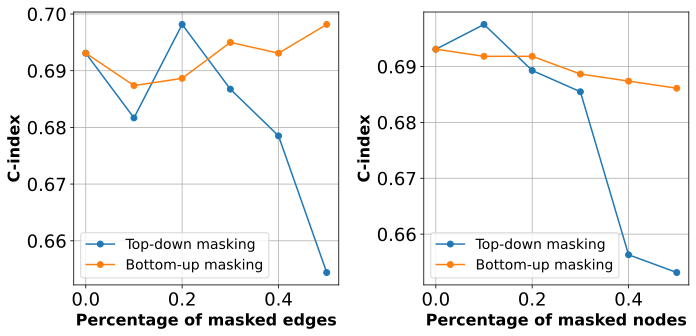

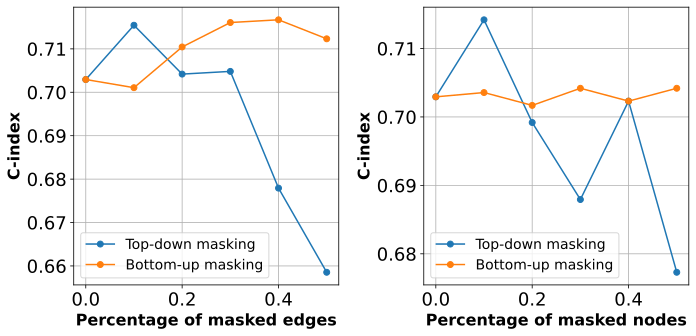

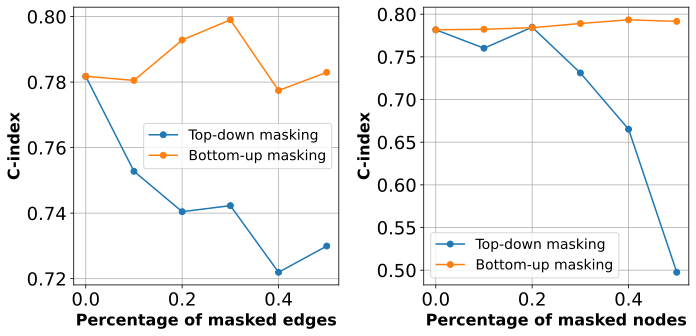

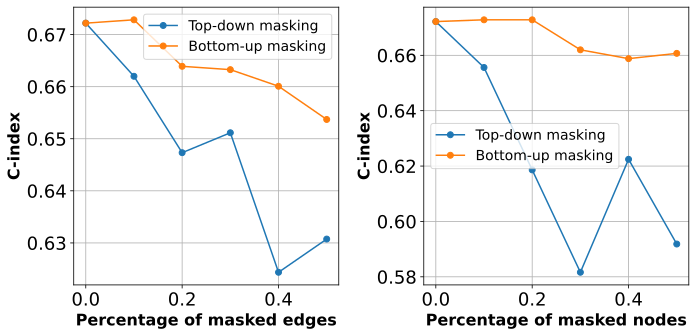

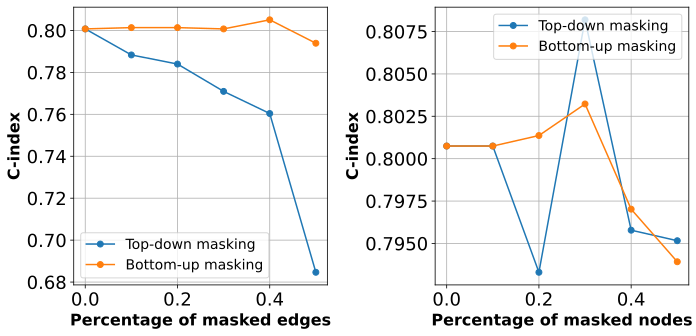

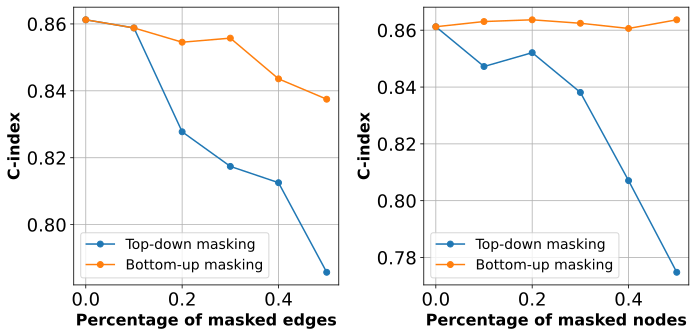

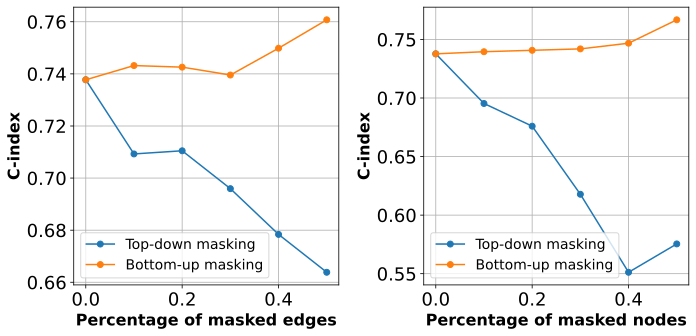

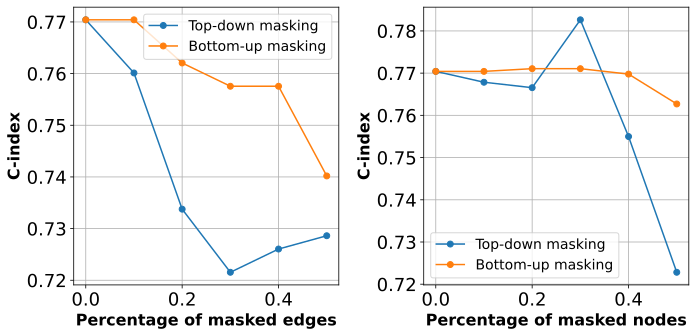

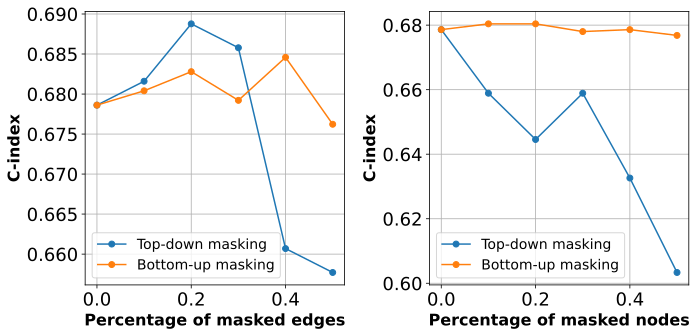

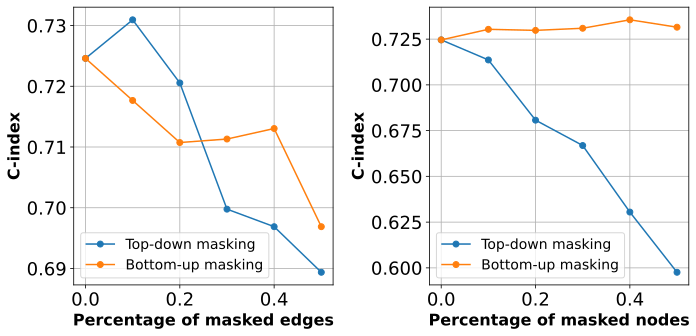

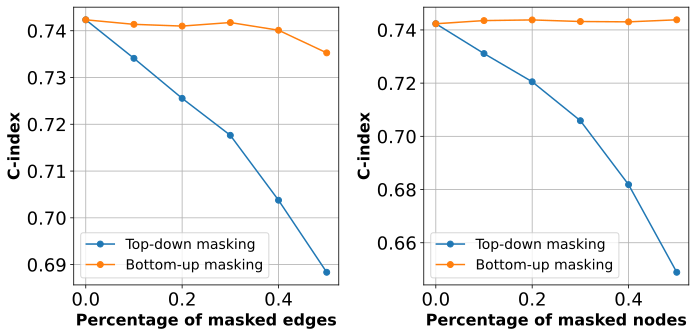

In [23]:
td_h_10s,td_n_10s,bu_h_10s,bu_n_10s = get_borda_score_10seeds(HD,PK_D,dataset,data)
td_h,td_n,bu_h,bu_n = np.array(td_h_10s).mean(axis=0),np.array(td_n_10s).mean(axis=0),np.array(bu_h_10s).mean(axis=0),np.array(bu_n_10s).mean(axis=0)

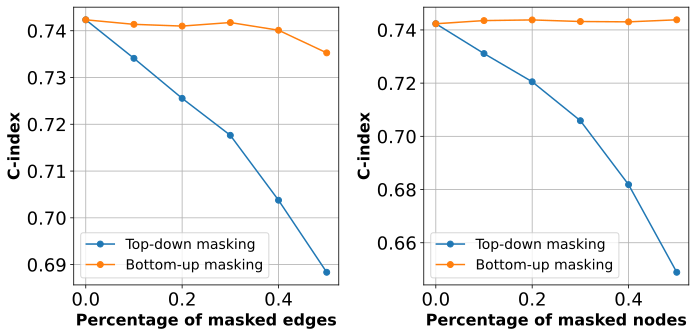

In [15]:
percent_space = np.linspace(0, 0.5, num=round(0.5 * 10 + 1))
plot_bs_validation("10mean",percent_space,td_h,bu_h,percent_space,td_n,bu_n)

# ROC DCA

iter      1: loss = 1.0395573151
iter      2: loss = 3.8360240455
iter      1: loss increased, performing step-halving. loss = 1.1288666606
iter      3: loss = 1.1739918805
iter      2: loss increased, performing step-halving. loss = 1.3116441911
iter      4: loss = 0.9607233922
iter      5: loss = 0.8579284596
iter      6: loss = 0.8157601328
iter      7: loss = 0.8013913146
iter      8: loss = 0.7990420456
iter      9: loss = 0.7988827774
iter     10: loss = 0.7988802284
iter     11: loss = 0.7988802257
iter     12: loss = 0.7988802257
iter     12: optimization converged
ci_eval = 0.603110599078341; ci_test = 0.7669962917181706


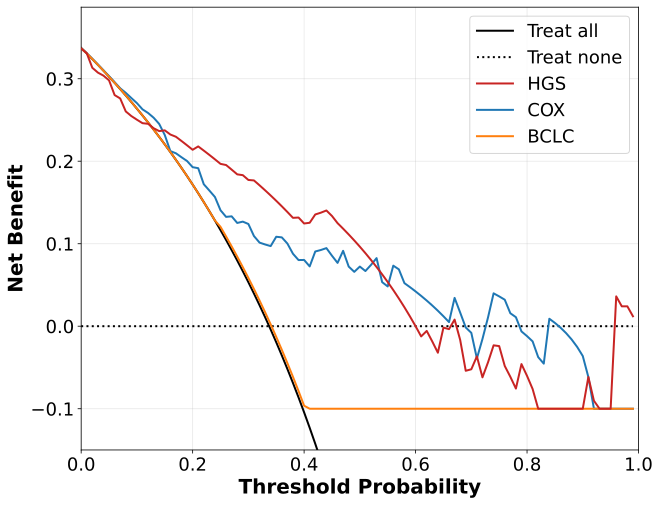

In [9]:
RD = collections.defaultdict(list)
# HGS risk
RD['test_risk'].append(get_risk_dis(data_test,model))
RD['val_risk'].append(get_risk_dis(data_valid,model))
RD['models_name'].append('HGS')

# COX risk
HD_cox = {
    'alpha':0.1,
    'ties':"breslow",
    # 'n_iter':5
}
fn_ckpt_cox = f"Results/cox"
ckpt = COX_train_eval(data_train=data_train,data_eval=data_valid,data_test=data_test,HD=HD_cox,fn=fn_ckpt_cox)

RD['test_risk'].append(minmax_scale(ckpt['pred_test']))
RD['val_risk'].append(minmax_scale(ckpt['pred_eval']))
RD['models_name'].append('COX')

# BCLC risk
path_clin = "data/Clinical/"
df_g = pd.read_csv(f"{path_clin}/Gao_clinical_phase.csv",index_col=0)
df_x = pd.read_csv(f"{path_clin}/Xing_clinical_phase.csv",index_col=0)
df_j = pd.read_csv(f"{path_clin}/Jiang_clinical_phase.csv",index_col=0)

dfs = [df_j,df_g,df_x]
BCLC_test = []
for df in dfs:
    BCLC_test.append(df.loc[df_test.index[df_test.index.isin(df.index)],'BCLC stage'])
BCLC_test = pd.DataFrame(pd.concat(BCLC_test,axis=0),columns=['BCLC stage'])
def BCLC_risk(BCLC_stage):
    if BCLC_stage == '0':
        return 0.25
    elif BCLC_stage == 'A':
        return 0.5
    elif BCLC_stage == 'B':
        return 0.75
    elif BCLC_stage == 'C':
        return 1.0
    else:
        return 1
    
BCLC_test['BCLC_risk'] = BCLC_test['BCLC stage'].apply(BCLC_risk)
RD['test_risk'].append(BCLC_test['BCLC_risk'].values)
RD['models_name'].append('BCLC')

# from utils.draw import *
bms=[]
title = ""
thresh_group = np.arange(0,1,0.01)
y_label = data_test[:,-1]
for risk in RD['test_risk']:
    bms.append(calculate_net_benefit_model(thresh_group, risk, y_label,))
net_benefit_all, net_benefit_none = calculate_net_benefit_all(thresh_group, y_label)
# plt.figure(figsize=(10, 8))
fig, ax = plt.subplots(figsize=(10, 8))

ax = plot_DCA(ax, thresh_group, bms, RD['models_name'],net_benefit_all,net_benefit_none,0,1,['HGS','COX','BCLC'],title=title,fs = fs_base)
# plt.savefig(f'images/DCA/{title}.png', dpi=300, bbox_inches='tight')

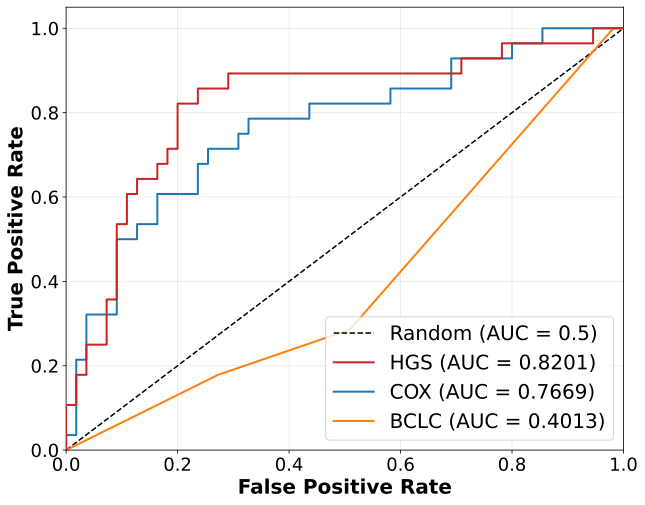

In [7]:
year = 5
label_y = get_label_n_year(data_test,s = year*4)
risk_HGS_y = get_risk_dis_year(data_test,year =year,model = model)
plot_ROCs(fs_base=fs_base,
    y_scores_list=[risk_HGS_y]+RD['test_risk'][1:],
    model_names=['HGS']+RD['models_name'][1:],
    y_true=np.int_(label_y[:,1]),
    # title = f"ROC_curves_comparing_HGS_and_clinical_methods_at_year_{year}")
    title = f"")
        


# HGS Benchmark

In [ ]:
# for Benchmark Reproduction：Run baseline_xxxx_GS.py and HGS_GS.py scripts

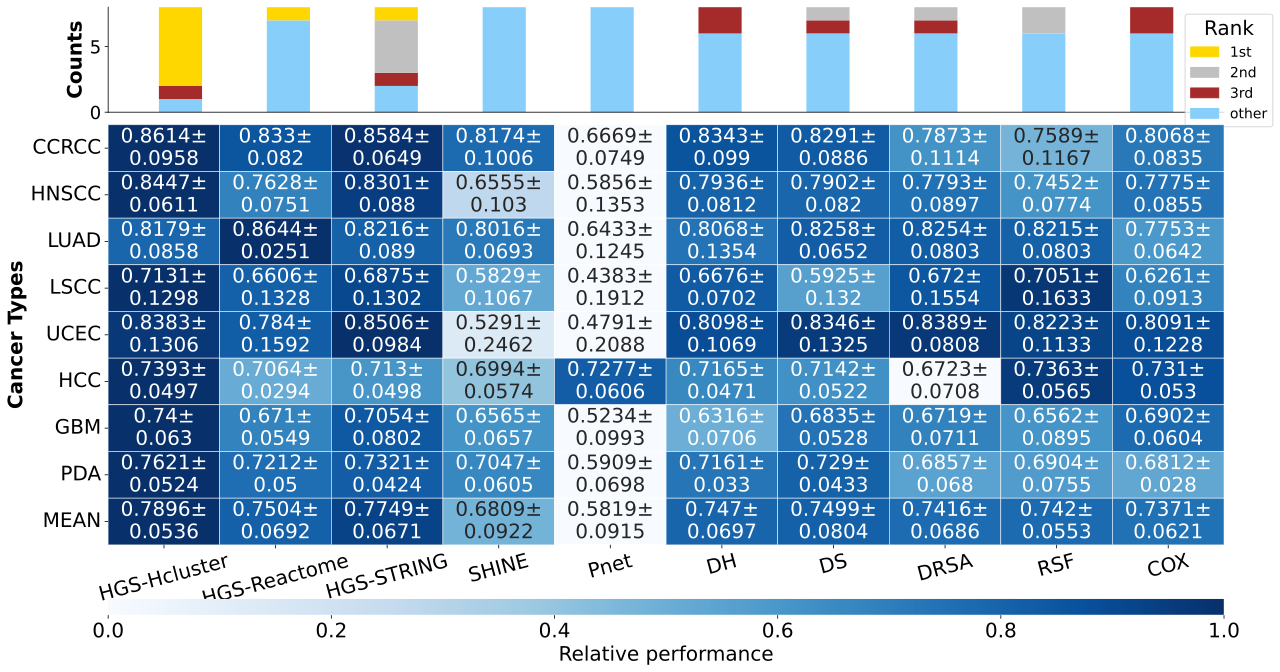

In [ ]:

data = {
    'cancers': ['CCRCC', 'HNSCC', 'LUAD', 'LSCC', 'UCEC', 'HCC', 'GBM', 'PDA', 'MEAN'],
    'HGS-Hcluster':         
        ['0.8614±\n0.0958', '0.8447±\n0.0611', '0.8179±\n0.0858', '0.7131±\n0.1298', 
        '0.8383±\n0.1306', '0.7393±\n0.0497', '0.74±\n0.063', '0.7621±\n0.0524','0.7896±\n0.0536'],        

    'HGS-Reactome': ['0.833±\n0.082', '0.7628±\n0.0751', '0.8644±\n0.0251', '0.6606±\n0.1328', '0.784±\n0.1592', 
        '0.7064±\n0.0294', '0.671±\n0.0549', '0.7212±\n0.05','0.7504±\n0.0692'],

    'HGS-STRING': ['0.8584±\n0.0649', '0.8301±\n0.088', '0.8216±\n0.089', '0.6875±\n0.1302', '0.8506±\n0.0984', 
        '0.713±\n0.0498', '0.7054±\n0.0802', '0.7321±\n0.0424','0.7749±\n0.0671'],
    'SHINE':['0.8174±\n0.1006', '0.6555±\n0.103', '0.8016±\n0.0693', '0.5829±\n0.1067', '0.5291±\n0.2462', 
        '0.6994±\n0.0574', '0.6565±\n0.0657', '0.7047±\n0.0605','0.6809±\n0.0922'],
        'Pnet':['0.6669±\n0.0749', '0.5856±\n0.1353', '0.6433±\n0.1245', '0.4383±\n0.1912',
        '0.4791±\n0.2088', '0.7277±\n0.0606', '0.5234±\n0.0993', '0.5909±\n0.0698','0.5819±\n0.0915'],

    'DH': ['0.8343±\n0.099', '0.7936±\n0.0812', '0.8068±\n0.1354', '0.6676±\n0.0702', '0.8098±\n0.1069', 
            '0.7165±\n0.0471', '0.6316±\n0.0706', '0.7161±\n0.033', '0.747±\n0.0697'],

    'DS': ['0.8291±\n0.0886', '0.7902±\n0.082', '0.8258±\n0.0652', '0.5925±\n0.132', '0.8346±\n0.1325', 
        '0.7142±\n0.0522', '0.6835±\n0.0528', '0.729±\n0.0433','0.7499±\n0.0804'],

    'DRSA': ['0.7873±\n0.1114', '0.7793±\n0.0897', '0.8254±\n0.0803', '0.672±\n0.1554', 
        '0.8389±\n0.0808', '0.6723±\n0.0708', '0.6719±\n0.0711', '0.6857±\n0.068','0.7416±\n0.0686'],

    "RSF": [
            "0.7589±\n0.1167",
            "0.7452±\n0.0774",
            "0.8215±\n0.0803",
            "0.7051±\n0.1633",
            "0.8223±\n0.1133",
            "0.7363±\n0.0565",
            "0.6562±\n0.0895",
            "0.6904±\n0.0755",
            "0.742±\n0.0553"
        ],
        
    "COX": [
            "0.8068±\n0.0835",
            "0.7775±\n0.0855",
            "0.7753±\n0.0642",
            "0.6261±\n0.0913",
            "0.8091±\n0.1228",
            "0.731±\n0.053",
            "0.6902±\n0.0604",
            "0.6812±\n0.028",
            "0.7371±\n0.0621"
            ],}

plot_heat_bar_rank(data,fs_base)

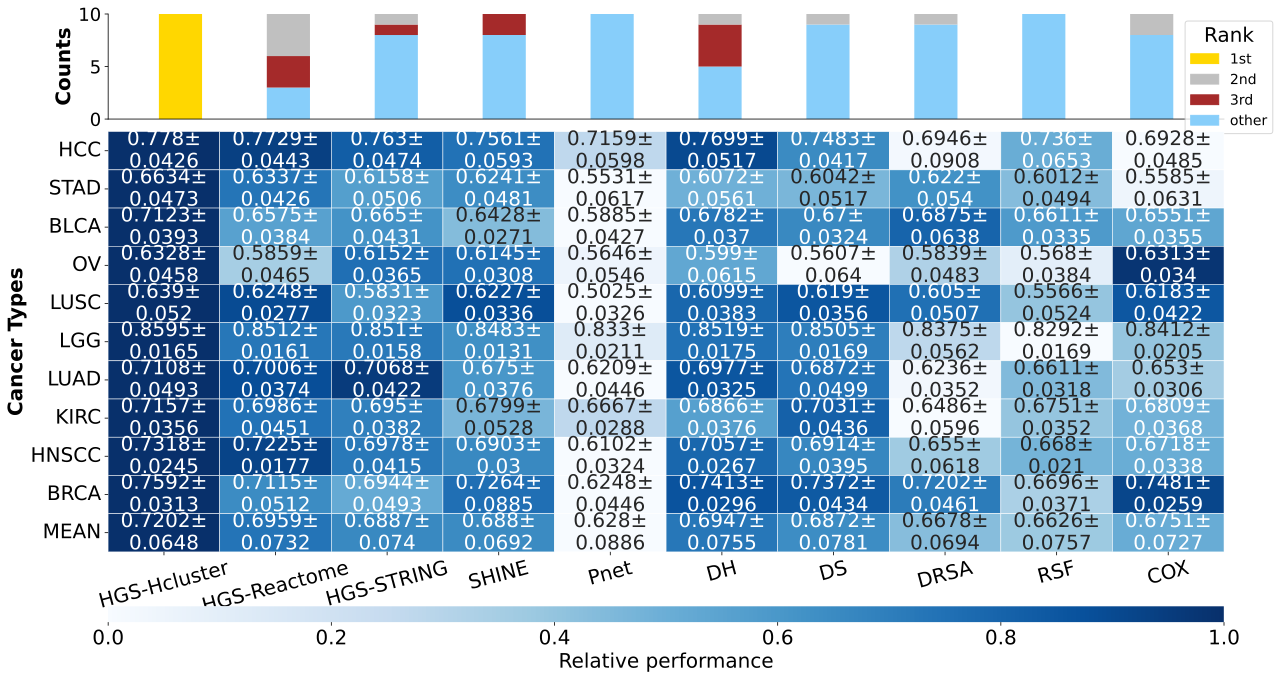

In [ ]:
data = {
    'cancers': ['HCC', 'STAD', 'BLCA', 'OV', 'LUSC', 'LGG', 'LUAD', 'KIRC', 'HNSCC', 'BRCA', 'MEAN'],
    'HGS-Hcluster': ['0.778±\n0.0426', '0.6634±\n0.0473', '0.7123±\n0.0393', '0.6328±\n0.0458', '0.639±\n0.052', 
    '0.8595±\n0.0165', '0.7108±\n0.0493', '0.7157±\n0.0356', '0.7318±\n0.0245', '0.7592±\n0.0313','0.7202±\n0.0648'],

    'HGS-Reactome':['0.7729±\n0.0443', '0.6337±\n0.0426', '0.6575±\n0.0384', '0.5859±\n0.0465', '0.6248±\n0.0277', 
    '0.8512±\n0.0161', '0.7006±\n0.0374', '0.6986±\n0.0451', '0.7225±\n0.0177', '0.7115±\n0.0512','0.6959±\n0.0732'],

    'HGS-STRING': ['0.763±\n0.0474', '0.6158±\n0.0506', '0.665±\n0.0431', '0.6152±\n0.0365', '0.5831±\n0.0323', 
    '0.851±\n0.0158', '0.7068±\n0.0422', '0.695±\n0.0382', '0.6978±\n0.0415', '0.6944±\n0.0493','0.6887±\n0.074'],
    'SHINE':
        ['0.7561±\n0.0593', '0.6241±\n0.0481', '0.6428±\n0.0271', '0.6145±\n0.0308', '0.6227±\n0.0336',
        '0.8483±\n0.0131', '0.675±\n0.0376', '0.6799±\n0.0528', '0.6903±\n0.03', '0.7264±\n0.0885','0.688±\n0.0692'],
        
    'Pnet': ['0.7159±\n0.0598', '0.5531±\n0.0617', '0.5885±\n0.0427', '0.5646±\n0.0546', '0.5025±\n0.0326',
        '0.833±\n0.0211', '0.6209±\n0.0446', '0.6667±\n0.0288', '0.6102±\n0.0324', '0.6248±\n0.0446','0.628±\n0.0886'],
        
    'DH': ['0.7699±\n0.0517', '0.6072±\n0.0561', '0.6782±\n0.037', '0.599±\n0.0615', '0.6099±\n0.0383', 
        '0.8519±\n0.0175', '0.6977±\n0.0325', '0.6866±\n0.0376', '0.7057±\n0.0267', '0.7413±\n0.0296','0.6947±\n0.0755'],

    'DS': ['0.7483±\n0.0417', '0.6042±\n0.0517', '0.67±\n0.0324', '0.5607±\n0.064', '0.619±\n0.0356', '0.8505±\n0.0169', 
            '0.6872±\n0.0499', '0.7031±\n0.0436', '0.6914±\n0.0395', '0.7372±\n0.0434','0.6872±\n0.0781'],
    'DRSA': ['0.6946±\n0.0908', '0.622±\n0.054', '0.6875±\n0.0638', '0.5839±\n0.0483', '0.605±\n0.0507', 
        '0.8375±\n0.0562', '0.6236±\n0.0352', '0.6486±\n0.0596', '0.655±\n0.0618', '0.7202±\n0.0461','0.6678±\n0.0694'],
    'RSF': ['0.736±\n0.0653', '0.6012±\n0.0494', '0.6611±\n0.0335', '0.568±\n0.0384', '0.5566±\n0.0524',
        '0.8292±\n0.0169', '0.6611±\n0.0318', '0.6751±\n0.0352', '0.668±\n0.021', '0.6696±\n0.0371','0.6626±\n0.0757'],

    'COX': ['0.6928±\n0.0485', '0.5585±\n0.0631', '0.6551±\n0.0355', '0.6313±\n0.034', '0.6183±\n0.0422', 
            '0.8412±\n0.0205', '0.653±\n0.0306', '0.6809±\n0.0368', '0.6718±\n0.0338', '0.7481±\n0.0259','0.6751±\n0.0727'],
}
plot_heat_bar_rank(data,fs_base)

# Novelty Validation

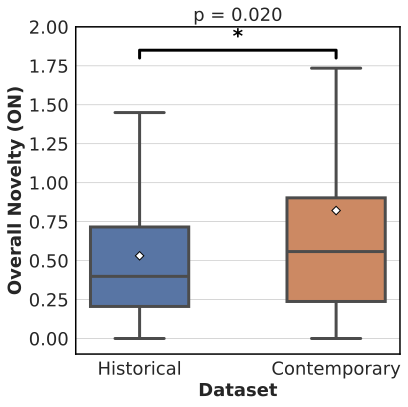

In [9]:
# load json
with open('data/Novelty/nov_val.json', 'r') as f:
    dict_p = json.load(f)

res_plot = pd.DataFrame(dict_p)
# 假设res_plot.iloc[4,0]和res_plot.iloc[4,1]是列表
data_past = pd.DataFrame({
    'Overall Novelty (ON)': res_plot.iloc[4,0],  # list
    'Dataset': 'Historical'
})
data_contemporary = pd.DataFrame({
    'Overall Novelty (ON)': res_plot.iloc[4,1],  # list
    'Dataset': 'Contemporary'
})
data = pd.concat([data_past, data_contemporary])

# 进行t检验
t_stat, p_value = ttest_ind(data_past['Overall Novelty (ON)'], 
                            data_contemporary['Overall Novelty (ON)'])

# 设置风格和颜色
sns.set_style("whitegrid")  # 白色网格背景
palette = {"Historical": "#4C72B0", "Contemporary": "#DD8452"}  # 蓝色和橙色

# 创建图形
plt.figure(figsize=(6, 6))

# 绘制箱线图
ax = sns.boxplot(
    x="Dataset", 
    y="Overall Novelty (ON)", 
    data=data, 
    palette=palette,
    width=0.5,
    linewidth=3,
    fliersize=0,  # 异常点大小
    showmeans=True,  # 显示均值
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"}  # 均值标记样式
)

# 美化图形
plt.xlabel("Dataset", fontsize=18, weight='bold')
plt.ylabel("Overall Novelty (ON)", fontsize=18, weight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(-0.1, 1.9)

# 添加显著性标记
y_max = 1.8  # 确定方括号的高度
bar_height = 0.05  # 方括号的高度
star_y = y_max + bar_height + 0.02  # 星号的位置

# 绘制方括号
plt.plot([0, 0, 1, 1], 
         [y_max, y_max + bar_height, y_max + bar_height, y_max], 
         lw=3, color='black')

# 添加星号表示显著性水平
if p_value < 0.001:
    stars = '***'
elif p_value < 0.01:
    stars = '**'
elif p_value < 0.05:
    stars = '*'
else:
    stars = 'n.s.'  # 不显著

plt.text(0.5, star_y, stars, ha='center', va='bottom', color='black', fontsize=20,weight='bold')
plt.title(f"p = {p_value:.3f}",fontsize=18)
# 调整y轴限制以容纳显著性标记
plt.ylim(-0.1, 2)

# 显示图形
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # 设置边框粗细
    spine.set_color("black")  
plt.show()